# 06 — GNN classica (EdgeConv) per Anomaly Detection
### Emerging Jets vs QCD

In questo notebook usiamo una **Graph Neural Network "classica"**: a differenza del Transformer
(dove ogni traccia parla con tutte le altre tramite l'attenzione), qui costruiamo un **grafo
esplicito e sparso** e facciamo passare i messaggi **solo lungo gli archi**.

**Cos'è una GNN classica, intuitivamente.**
1. Mettiamo ogni traccia come **nodo** di un grafo.
2. Tracciamo gli **archi** collegando ogni traccia alle sue **k vicine** nel piano angolare
   (η, φ) — è il *grafo kNN*: due tracce vicine in direzione sono collegate.
3. Ogni nodo aggiorna la sua rappresentazione **guardando solo i vicini** collegati
   (*message passing*), con un'operazione fissa (qui **EdgeConv**: per ogni vicino calcola una
   "feature di arco", poi tiene il massimo). **Nessuna attenzione**: gli archi sono decisi dalla
   geometria, non da pesi imparati.

**Differenza con il Transformer (notebook 07, la GNN con attenzione):**
| | grafo | come "parlano" le tracce |
|---|---|---|
| Transformer | completo (tutti-con-tutti) | attenzione (pesi imparati) |
| **GNN classica (qui)** | **sparso (kNN in η-φ)** | **message passing senza attenzione** |

**Come la usiamo per l'anomaly detection.**
Costruiamo un **autoencoder sul grafo**: comprimiamo e ricostruiamo le feature di ogni traccia
sfruttando i vicini. Alleniamo **solo su QCD**; lo score è **quanto male ricostruisce le tracce**
di un jet (alto = anomalo). Stesso criterio degli altri modelli, così il confronto è diretto.

> **Premessa — è una GNN a tutti gli effetti.** Il blocco che usiamo, **EdgeConv**, è
> un'operazione di *message passing* standard (dal paper *Dynamic Graph CNN for Learning on
> Point Clouds*, Wang et al. 2019) ed è la base di **ParticleNet**, la GNN di riferimento per i
> jet in fisica delle particelle. Quindi questo modello è una **GNN classica nel senso pieno del
> termine** (grafo esplicito + message passing, senza attenzione), difendibile come tale.
> *(Dettaglio: usiamo un grafo kNN **statico** in η-φ; ParticleNet lo ricalcola in modo dinamico
> nello spazio delle feature — entrambe sono varianti valide di GNN.)*


---
## 1. Setup e iperparametri

> **In breve.** Carichiamo gli strumenti e fissiamo le impostazioni. La manopola nuova rispetto
> agli altri modelli è **`K`**: quanti vicini collega ogni traccia nel grafo (la "densità" del
> grafo). Le altre sono la larghezza della rete, la dimensione del collo di bottiglia e quanti
> strati di message passing.


In [8]:
import os, sys, gc, warnings
warnings.filterwarnings('ignore')
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

PROJECT_DIR = r'C:\Users\dfraj\OneDrive\Desktop\Master\Adv_ML\Progetto\ej_anomaly'
sys.path.insert(0, PROJECT_DIR)
from Utils_NEW import load_tracks, clean_tracks, zscore_normalise, compute_roc, plot_roc, TRACK_FEATURES

BKG_FILE = r'C:\Users\dfraj\Downloads\pp_output_test_background.h5'
SIG_FILE = r'C:\Users\dfraj\Downloads\pp_output_test_signal.h5'
MODELS_DIR = os.path.join(PROJECT_DIR, 'models'); PLOTS_DIR = os.path.join(PROJECT_DIR, 'plots')
os.makedirs(MODELS_DIR, exist_ok=True); os.makedirs(PLOTS_DIR, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
print(f'Device: {DEVICE}')

# indici delle coordinate angolari nel vettore di feature (per costruire il grafo kNN)
DPHI = TRACK_FEATURES.index('dphi')
DETA = TRACK_FEATURES.index('deta')

# ── Iperparametri ─────────────────────────────────────────────────────────────
# Rappresentazione traccia-per-traccia: pesante in RAM. Se OOM, abbassa N_BKG_TRAIN/N_SIG_EVAL/TMAX.
N_BKG_TRAIN = 50_000
N_SIG_EVAL  = 50_000
TMAX        = 64         # max tracce per jet (le piu' energetiche)

K           = 8          # numero di vicini nel grafo kNN (densita' del grafo)
EMBED_DIM   = 64         # larghezza delle reti EdgeConv
N_LAYERS    = 2          # numero di strati di message passing (EdgeConv)
LATENT      = 8          # collo di bottiglia per nodo

LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-5
BATCH_SIZE    = 256
N_EPOCHS      = 80
PATIENCE      = 15

TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.15, 0.15
SAVE_PATH = os.path.join(MODELS_DIR, f'gnn_edgeconv_K{K}_d{EMBED_DIM}.pt')
print(f'Setup OK -> EdgeConv GNN: K={K} vicini, {N_LAYERS} strati x {EMBED_DIM}, bottleneck {LATENT}')


Device: cpu
Setup OK -> EdgeConv GNN: K=8 vicini, 2 strati x 64, bottleneck 8


---
## 2. Dati: le tracce come nodi

> **In breve.** Per ogni jet teniamo le sue tracce (max `TMAX`, le più energetiche), ognuna con
> le 14 feature già normalizzate. È la stessa rappresentazione traccia-per-traccia del Transformer
> — la differenza è solo *come* le faremo interagire (grafo kNN invece di attenzione).


In [9]:
def prep_tracks(path, n_max, Tmax=TMAX):
    '''Carica i jet in forma (N, Tmax, 14) + maschera, tenendo le tracce a pT piu alto.'''
    tr = load_tracks(path, n_max=n_max); m = tr['valid'].astype(bool)
    Xc, m = clean_tracks(tr, m); Xn = zscore_normalise(Xc, m)
    del Xc, tr; gc.collect()
    pt = np.where(m, Xn[:, :, 0], -1e9); order = np.argsort(-pt, axis=1)
    Xs = np.take_along_axis(Xn, order[:, :, None], axis=1)[:, :Tmax].astype(np.float32)
    ms = np.take_along_axis(m, order, axis=1)[:, :Tmax]
    del Xn, m, pt, order; gc.collect()
    return Xs, ms

print('Caricamento background (QCD)...'); X_bkg, M_bkg = prep_tracks(BKG_FILE, N_BKG_TRAIN)
print('Caricamento segnale (EJ)...');     X_sig, M_sig = prep_tracks(SIG_FILE, N_SIG_EVAL)
F = X_bkg.shape[2]
print(f'X_bkg {X_bkg.shape} | X_sig {X_sig.shape} | tracce valide medie {M_bkg.sum(1).mean():.1f}')


Caricamento background (QCD)...
Caricamento segnale (EJ)...
X_bkg (50000, 64, 14) | X_sig (50000, 64, 14) | tracce valide medie 52.7


---
## 3. Costruzione del grafo: kNN in (η, φ)

> **In breve.** Qui definiamo *come* colleghiamo le tracce: ogni traccia viene collegata alle sue
> **K più vicine** nel piano angolare (η, φ). Disegniamo anche il grafo di un jet QCD e di un jet
> EJ, per *vedere* com'è fatto.

Perché (η, φ)? È lo spazio fisico naturale del jet: tracce vicine in direzione tendono ad
appartenere alla stessa sotto-struttura. Collegando i vicini, diamo al modello la possibilità di
confrontare ogni traccia col suo intorno locale — è l'informazione che un semplice riassunto
aggregato perderebbe.

Il grafico sotto mostra le tracce come punti (η, φ) e gli archi verso i K vicini: a sinistra un
jet QCD, a destra un Emerging Jet. Spesso negli EJ la disposizione delle tracce è diversa
(displaced) — ed è proprio questo che la GNN può cogliere.


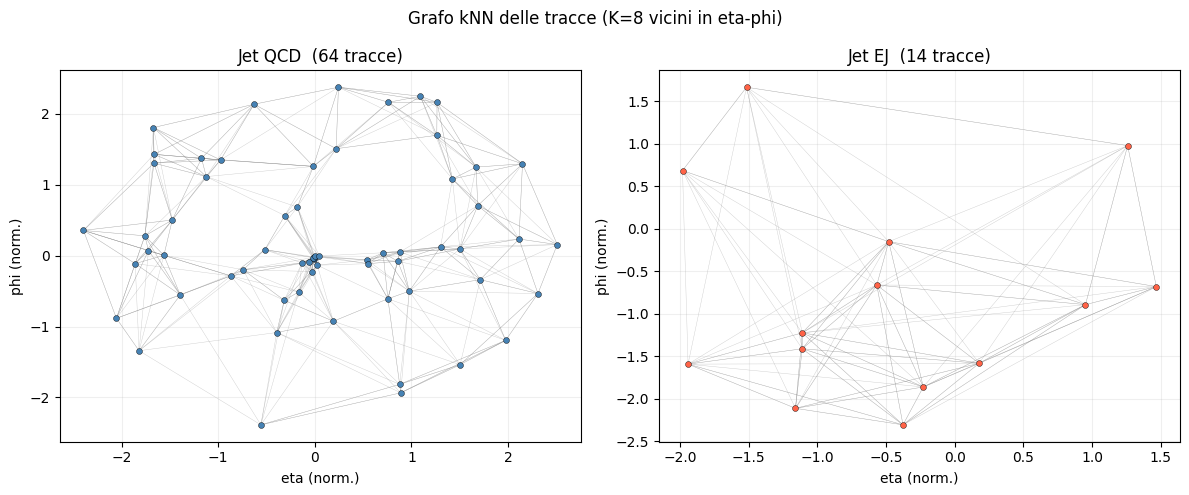

In [10]:
def draw_jet_graph(ax, x_jet, mask_jet, k, title):
    '''Disegna il grafo kNN di un singolo jet nel piano (eta, phi).'''
    v = np.where(mask_jet)[0]
    eta, phi = x_jet[v, DETA], x_jet[v, DPHI]
    pts = np.stack([eta, phi], axis=1)
    D = np.linalg.norm(pts[:, None, :] - pts[None, :, :], axis=-1)
    np.fill_diagonal(D, 1e9)
    kk = min(k, len(v) - 1)
    nn_idx = np.argsort(D, axis=1)[:, :kk]
    for i in range(len(v)):                       # archi verso i k vicini
        for j in nn_idx[i]:
            ax.plot([eta[i], eta[j]], [phi[i], phi[j]], color='gray', lw=0.3, alpha=0.4, zorder=1)
    ax.scatter(eta, phi, s=18, c='tomato' if 'EJ' in title else 'steelblue', zorder=2, edgecolors='k', linewidths=0.3)
    ax.set_title(f'{title}  ({len(v)} tracce)'); ax.set_xlabel('eta (norm.)'); ax.set_ylabel('phi (norm.)')
    ax.grid(alpha=0.2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
draw_jet_graph(axes[0], X_bkg[0], M_bkg[0], K, 'Jet QCD')
draw_jet_graph(axes[1], X_sig[0], M_sig[0], K, 'Jet EJ')
plt.suptitle(f'Grafo kNN delle tracce (K={K} vicini in eta-phi)')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'gnn_edgeconv_grafo.png'), dpi=130, bbox_inches='tight')
plt.show()


---
## 4. Split dei dati

> **In breve.** Dividiamo i jet QCD in allenamento / controllo / test (70/15/15). Il segnale resta
> da parte fino alla valutazione finale.


In [11]:
rng = np.random.default_rng(SEED); perm = rng.permutation(len(X_bkg))
n_tr = int(len(X_bkg)*TRAIN_FRAC); n_vl = int(len(X_bkg)*VAL_FRAC)
itr, ivl, ite = perm[:n_tr], perm[n_tr:n_tr+n_vl], perm[n_tr+n_vl:]
Xtr, Mtr = X_bkg[itr], M_bkg[itr]
Xvl, Mvl = X_bkg[ivl], M_bkg[ivl]
Xte, Mte = X_bkg[ite], M_bkg[ite]
train_loader = DataLoader(TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(Mtr)),
                          batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
n_val = len(Xvl)
print(f'TRAIN {len(Xtr)} | VAL {n_val} | TEST {len(Xte)} | SIG {len(X_sig)}')


TRAIN 35000 | VAL 7500 | TEST 7500 | SIG 50000


---
## 5. Il modello: EdgeConv autoencoder

> **In breve.** Definiamo il cuore della GNN classica: l'operazione **EdgeConv**. Per ogni traccia
> e ognuno dei suoi K vicini si costruisce una "feature di arco" `[traccia, vicino − traccia]`, la
> si passa in una piccola rete, e si tiene il **massimo** sui vicini. Niente attenzione: tutti i
> vicini contano, e la rete impara cosa estrarre dal confronto locale.

L'autoencoder è: alcuni strati EdgeConv (le tracce assorbono il contesto dei vicini) → **collo di
bottiglia** per nodo → ricostruzione delle 14 feature di ogni traccia. Il grafo kNN è **statico**
(calcolato una volta in η-φ) e condiviso da tutti gli strati.


In [12]:
def build_knn(coord, mask, k):
    '''Per ogni traccia trova i k vicini in (eta,phi); esclude se stesso e il padding.'''
    B, T, _ = coord.shape
    d = torch.cdist(coord, coord)                              # (B,T,T) distanze angolari
    big = 1e9
    d = d + (~mask).unsqueeze(1).float() * big                # il padding non puo' essere vicino
    d = d + torch.eye(T, device=coord.device).unsqueeze(0)*big  # escludi se stesso
    return d.topk(k, dim=-1, largest=False).indices           # (B,T,k) indici dei vicini

def gather_neighbors(h, idx):
    '''Raccoglie le feature dei vicini: (B,T,C) + (B,T,k) -> (B,T,k,C).'''
    B, T, C = h.shape
    h_exp = h.unsqueeze(1).expand(-1, T, -1, -1)
    idx_e = idx.unsqueeze(-1).expand(-1, -1, -1, C)
    return torch.gather(h_exp, 2, idx_e)

def edge_conv(h, idx, mlp):
    '''Un passo di message passing EdgeConv (max-aggregation sui vicini).'''
    k = idx.shape[-1]
    central = h.unsqueeze(2).expand(-1, -1, k, -1)            # la traccia centrale
    nb = gather_neighbors(h, idx)                             # i suoi vicini
    edge = torch.cat([central, nb - central], dim=-1)        # [traccia, vicino - traccia]
    return mlp(edge).max(dim=2).values                        # aggregazione MAX -> nuova feature

class EdgeConvAE(nn.Module):
    '''Autoencoder su grafo: EdgeConv (message passing) + ricostruzione per-nodo.'''
    def __init__(self, feat, k=8, d=64, latent=8, n_layers=2):
        super().__init__(); self.k = k
        self.convs = nn.ModuleList()
        in_c = feat
        for _ in range(n_layers):
            self.convs.append(nn.Sequential(nn.Linear(2*in_c, d), nn.ReLU(), nn.Linear(d, d), nn.ReLU()))
            in_c = d
        self.to_latent = nn.Linear(d, latent)                 # collo di bottiglia
        self.dec = nn.Sequential(nn.Linear(latent, d), nn.ReLU(), nn.Linear(d, d), nn.ReLU())
        self.out = nn.Linear(d, feat)                         # ricostruzione delle 14 feature
    def forward(self, x, mask):
        coord = x[:, :, [DETA, DPHI]]
        idx = build_knn(coord, mask, self.k)                  # grafo kNN statico in (eta,phi)
        h = x
        for conv in self.convs:
            h = edge_conv(h, idx, conv)                       # message passing
        return self.out(self.dec(self.to_latent(h)))

def masked_node_mse(xrec, x, mask):
    '''Errore di ricostruzione per jet: MSE per traccia, mediato sulle tracce valide.'''
    e = ((xrec - x) ** 2).mean(-1) * mask
    return e.sum(1) / mask.sum(1).clamp(min=1)

def build_model(k, d, latent, n_layers):
    return EdgeConvAE(F, k=k, d=d, latent=latent, n_layers=n_layers)

model = build_model(K, EMBED_DIM, LATENT, N_LAYERS).to(DEVICE)
print(f'EdgeConv GNN -> {sum(p.numel() for p in model.parameters()):,} parametri')


EdgeConv GNN -> 24,598 parametri


---
## 6. Addestramento (solo su QCD)

> **In breve.** Alleniamo l'autoencoder a ricostruire bene le tracce dei jet QCD; minimizziamo
> l'errore di ricostruzione. Selezioniamo il modello sull'errore dei jet di **controllo** (sempre
> solo QCD); il segnale non viene mai usato.


In [13]:
opt   = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=max(1, PATIENCE//3), factor=0.5)
Xvl_t, Mvl_t = torch.from_numpy(Xvl), torch.from_numpy(Mvl)
best_val, wait = float('inf'), 0
train_losses, val_losses = [], []
print(f'{"Epoca":>6} {"Train loss":>12} {"Val loss":>12} {"LR":>10}')
print('-'*44)
for epoch in range(1, N_EPOCHS+1):
    model.train(); tot = 0.0
    for xb, mb in train_loader:
        xb, mb = xb.to(DEVICE), mb.to(DEVICE)
        loss = masked_node_mse(model(xb, mb), xb, mb).mean()
        opt.zero_grad(); loss.backward(); opt.step()
        tot += loss.item() * len(xb)
    train_loss = tot / len(train_loader.dataset)
    model.eval()
    with torch.no_grad():
        xv, mv = Xvl_t.to(DEVICE), Mvl_t.to(DEVICE)
        val_loss = masked_node_mse(model(xv, mv), xv, mv).mean().item()
    sched.step(val_loss)
    train_losses.append(train_loss); val_losses.append(val_loss)
    if epoch % 5 == 0 or epoch == 1:
        print(f'{epoch:>6} {train_loss:>12.4f} {val_loss:>12.4f} {opt.param_groups[0]["lr"]:>10.2e}')
    if val_loss < best_val - 1e-5:
        best_val, wait = val_loss, 0; torch.save(model.state_dict(), SAVE_PATH)
    else:
        wait += 1
        if wait >= PATIENCE: print(f'Early stopping a epoca {epoch}'); break
model.load_state_dict(torch.load(SAVE_PATH, weights_only=True))
print(f'\nBest val loss = {best_val:.4f}')


 Epoca   Train loss     Val loss         LR
--------------------------------------------
     1       0.5625       0.2559   1.00e-03
     5       0.0605       0.0552   1.00e-03
    10       0.0385       0.0375   1.00e-03
    15       0.0325       0.0320   1.00e-03
    20       0.0282       0.0276   1.00e-03
    25       0.0235       0.0229   1.00e-03
    30       0.0210       0.0209   1.00e-03
    35       0.0196       0.0194   1.00e-03
    40       0.0183       0.0183   1.00e-03
    45       0.0174       0.0179   1.00e-03
    50       0.0165       0.0165   1.00e-03
    55       0.0157       0.0160   1.00e-03
    60       0.0148       0.0145   1.00e-03
    65       0.0140       0.0137   1.00e-03
    70       0.0134       0.0130   1.00e-03
    75       0.0130       0.0133   1.00e-03
    80       0.0125       0.0124   1.00e-03

Best val loss = 0.0122


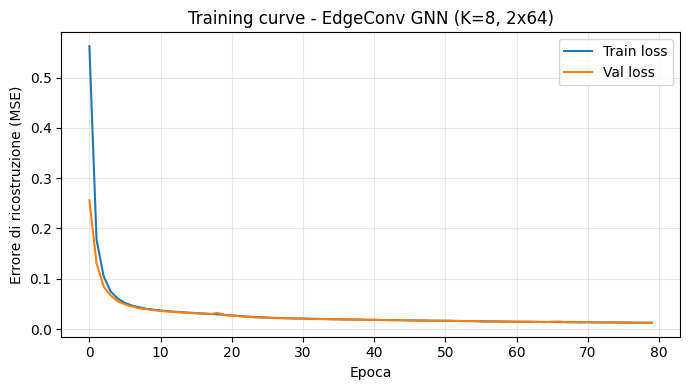

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(train_losses, label='Train loss'); ax.plot(val_losses, label='Val loss')
ax.set_xlabel('Epoca'); ax.set_ylabel('Errore di ricostruzione (MSE)')
ax.set_title(f'Training curve - EdgeConv GNN (K={K}, {N_LAYERS}x{EMBED_DIM})')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'gnn_edgeconv_training_curve.png'), dpi=130, bbox_inches='tight')
plt.show()


---
## 7. Anomaly score: errore di ricostruzione delle tracce

> **In breve.** Lo score di un jet è quanto male il modello (allenato sul QCD) ricostruisce le sue
> tracce, mediato sulle tracce del jet. QCD = score basso, EJ = score alto. Qui tocchiamo per la
> prima volta test-QCD e segnale (nessun leakage).


In [15]:
def gnn_score(model, X, M, batch=256):
    model.eval(); out = []
    with torch.no_grad():
        for st in range(0, len(X), batch):
            xb = torch.from_numpy(X[st:st+batch]).to(DEVICE); mb = torch.from_numpy(M[st:st+batch]).to(DEVICE)
            out.append(masked_node_mse(model(xb, mb), xb, mb).cpu().numpy())
    return np.concatenate(out)

scores_bkg = gnn_score(model, Xte, Mte); scores_sig = gnn_score(model, X_sig, M_sig)
print(f'QCD (test): {scores_bkg.mean():.4f} +/- {scores_bkg.std():.4f}')
print(f'EJ        : {scores_sig.mean():.4f} +/- {scores_sig.std():.4f}')
print(f'Delta (EJ - QCD): {scores_sig.mean()-scores_bkg.mean():+.4f}')


QCD (test): 0.0123 +/- 0.0076
EJ        : 0.0173 +/- 0.0086
Delta (EJ - QCD): +0.0050


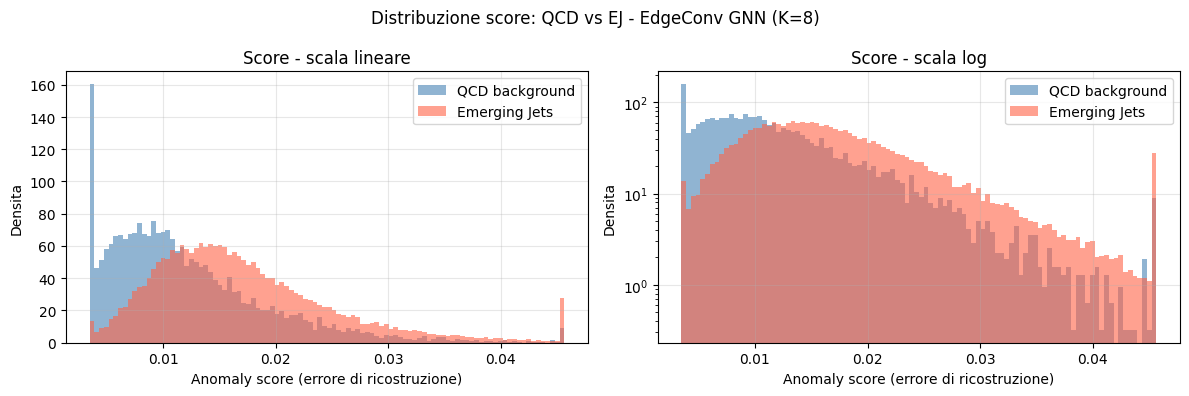

In [16]:
both = np.concatenate([scores_bkg, scores_sig])
lo, hi = np.percentile(both,1), np.percentile(both,99)
sb, ss = np.clip(scores_bkg,lo,hi), np.clip(scores_sig,lo,hi)
fig, axes = plt.subplots(1, 2, figsize=(12,4))
for ax, logy in zip(axes, [False, True]):
    ax.hist(sb, bins=100, density=True, alpha=0.6, label='QCD background', color='steelblue')
    ax.hist(ss, bins=100, density=True, alpha=0.6, label='Emerging Jets', color='tomato')
    ax.set_xlabel('Anomaly score (errore di ricostruzione)'); ax.set_ylabel('Densita')
    ax.set_title('Score - scala log' if logy else 'Score - scala lineare')
    if logy: ax.set_yscale('log')
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle(f'Distribuzione score: QCD vs EJ - EdgeConv GNN (K={K})')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'gnn_edgeconv_score_distributions.png'), dpi=130, bbox_inches='tight')
plt.show()


---
## 8. Valutazione — ROC, AUC e SIC

> **In breve.** Le solite metriche (ROC, AUC, SIC), identiche agli altri modelli per un confronto
> diretto.


VALUTAZIONE FINALE (test-QCD + segnale, mai visti in addestramento)
  Config : K=8, 2 strati EdgeConv x 64, bottleneck 8
  AUC    : 0.6990
  N test-QCD: 7,500  |  N segnale: 50,000


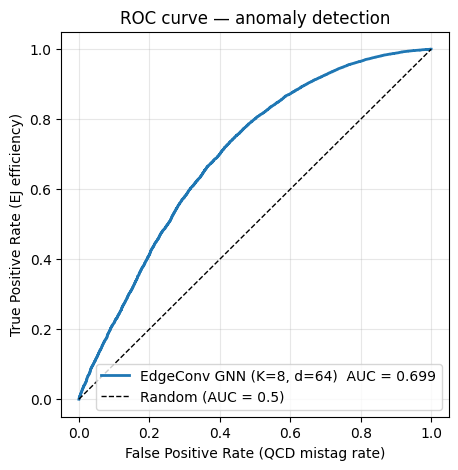

SIC massima : 1.135 @ eps_S = 0.81


In [17]:
fpr, tpr, roc_auc = compute_roc(scores_bkg, scores_sig)
print('='*55); print('VALUTAZIONE FINALE (test-QCD + segnale, mai visti in addestramento)'); print('='*55)
print(f'  Config : K={K}, {N_LAYERS} strati EdgeConv x {EMBED_DIM}, bottleneck {LATENT}')
print(f'  AUC    : {roc_auc:.4f}')
print(f'  N test-QCD: {len(scores_bkg):,}  |  N segnale: {len(scores_sig):,}')
plot_roc(fpr, tpr, roc_auc, label=f'EdgeConv GNN (K={K}, d={EMBED_DIM})',
         save_path=os.path.join(PLOTS_DIR, 'gnn_edgeconv_roc_finale.png'))
plt.show()
m = fpr > 0; sic = tpr[m]/np.sqrt(fpr[m])
print(f'SIC massima : {sic.max():.3f} @ eps_S = {tpr[m][sic.argmax()]:.2f}')


---
## 9. Tuning degli iperparametri

> **In breve.** Variamo le tre manopole tipiche: il **numero di vicini K** (densità del grafo), la
> **dimensione del bottleneck** (latent) e la **profondità** (quanti strati EdgeConv). Criterio
> sempre l'errore di ricostruzione sul QCD di controllo, mai il segnale. Per andare veloci, il
> tuning gira su un **sottoinsieme** (10k jet) e poche epoche: basta il confronto *relativo*.

Come per gli altri modelli: capacità (latent, profondità) → si sceglie il **gomito**; il numero
di vicini K si valuta sull'errore di validation. `K` è specifico della GNN classica: pochi vicini
= grafo molto locale, troppi = ci si avvicina al "tutti-con-tutti" del Transformer.


In [18]:
def train_for_tuning(k, d, latent, n_layers, n_epochs=12, patience=4, lr=1e-3, device=DEVICE):
    '''Allena una EdgeConv-AE su un sottoinsieme (solo QCD) e ritorna la miglior val-loss.'''
    torch.manual_seed(SEED)
    mdl = build_model(k, d, latent, n_layers).to(device)
    opt = torch.optim.Adam(mdl.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=2, factor=0.5)
    N_TUNE = 10000
    tl = DataLoader(TensorDataset(torch.from_numpy(Xtr[:N_TUNE]), torch.from_numpy(Mtr[:N_TUNE])),
                    batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
    xv, mv = torch.from_numpy(Xvl).to(device), torch.from_numpy(Mvl).to(device)
    best, wait = float('inf'), 0
    for _ in range(n_epochs):
        mdl.train()
        for xb, mb in tl:
            xb, mb = xb.to(device), mb.to(device)
            loss = masked_node_mse(mdl(xb, mb), xb, mb).mean()
            opt.zero_grad(); loss.backward(); opt.step()
        mdl.eval()
        with torch.no_grad():
            val = masked_node_mse(mdl(xv, mv), xv, mv).mean().item()
        sched.step(val)
        if val < best - 1e-5: best, wait = val, 0
        else:
            wait += 1
            if wait >= patience: break
    return best


In [19]:
# ━━━ Esperimento 1 - Numero di vicini K ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print('Esperimento 1: K (vicini)  (criterio: val-loss ricostruzione QCD)')
print(f"{'K':>5} | {'val loss':>12}"); print('-'*22)
k_results = {}
for kk in [4, 8, 16, 24]:
    k_results[kk] = train_for_tuning(kk, EMBED_DIM, LATENT, N_LAYERS)
    print(f'{kk:>5} | {k_results[kk]:>12.5f}')


Esperimento 1: K (vicini)  (criterio: val-loss ricostruzione QCD)
    K |     val loss
----------------------
    4 |      0.07537
    8 |      0.07646
   16 |      0.07313
   24 |      0.07855


In [20]:
# ━━━ Esperimento 2 - Latent dim (bottleneck) ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
print('Esperimento 2: latent  (criterio: val-loss ricostruzione QCD)')
print(f"{'latent':>7} | {'val loss':>12}"); print('-'*24)
lat_results = {}
for L in [4, 8, 16, 32]:
    lat_results[L] = train_for_tuning(K, EMBED_DIM, L, N_LAYERS)
    print(f'{L:>7} | {lat_results[L]:>12.5f}')


Esperimento 2: latent  (criterio: val-loss ricostruzione QCD)
 latent |     val loss
------------------------


      4 |      0.16787
      8 |      0.07646
     16 |      0.03665
     32 |      0.03675


In [21]:
# ━━━ Esperimento 3 - Profondita (numero di strati EdgeConv) ━━━━━━━━━━━━━━━━━━
print('Esperimento 3: profondita  (criterio: val-loss ricostruzione QCD)')
print(f"{'n_layers':>9} | {'val loss':>12}"); print('-'*26)
depth_results = {}
for ne in [1, 2, 3]:
    depth_results[ne] = train_for_tuning(K, EMBED_DIM, LATENT, ne)
    print(f'{ne:>9} | {depth_results[ne]:>12.5f}')


Esperimento 3: profondita  (criterio: val-loss ricostruzione QCD)
 n_layers |     val loss
--------------------------
        1 |      0.05760
        2 |      0.07646
        3 |      0.15370


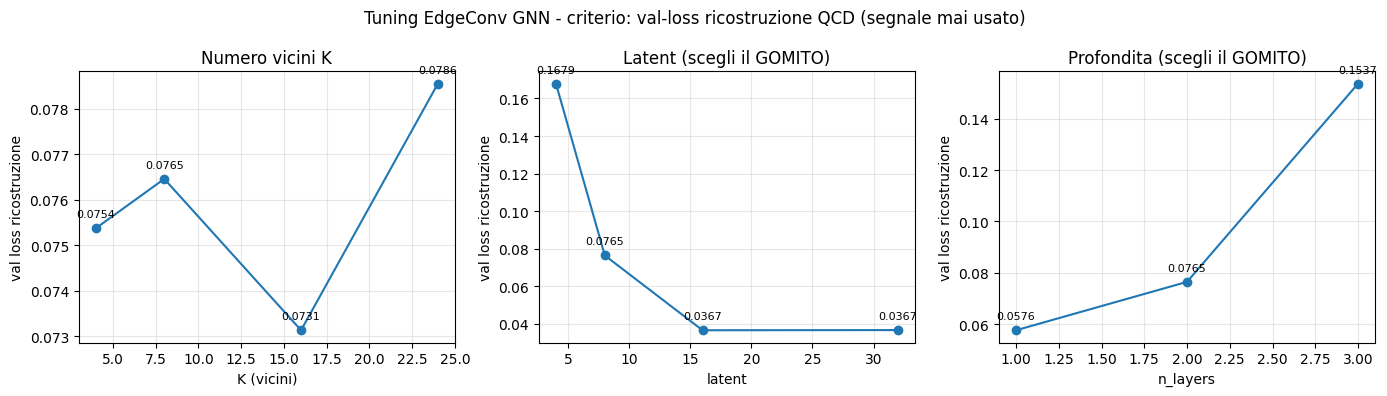

In [22]:
# ── Riepilogo del tuning ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (res, xlab, title) in zip(axes, [
        (k_results, 'K (vicini)', 'Numero vicini K'),
        (lat_results, 'latent', 'Latent (scegli il GOMITO)'),
        (depth_results, 'n_layers', 'Profondita (scegli il GOMITO)')]):
    ks, vs = list(res), list(res.values())
    ax.plot(ks, vs, 'o-'); ax.set_xlabel(xlab); ax.set_ylabel('val loss ricostruzione')
    ax.set_title(title); ax.grid(alpha=0.3)
    for k_, v in zip(ks, vs):
        ax.annotate(f'{v:.4f}', (k_, v), textcoords='offset points', xytext=(0,8), ha='center', fontsize=8)
plt.suptitle('Tuning EdgeConv GNN - criterio: val-loss ricostruzione QCD (segnale mai usato)')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'gnn_edgeconv_tuning_summary.png'), dpi=130, bbox_inches='tight')
plt.show()


## Scelta di design: whitening testato, non adottato

Abbiamo testato lo score **whitened** (errore per-feature normalizzato per la varianza di ricostruzione sul QCD), che migliora i modelli nello spazio *aggregate* (AE, VAE, diffusion). A livello di **traccia**, pero', **peggiora**: misurato sull'EdgeConv, AUC 0.699 -> 0.687. Il motivo: feature con errore di ricostruzione QCD piccolissimo (es. `numberOfInnermostPixelLayerHits`, ~0.001) vengono amplificate ~25x e sbilanciano lo score. Quindi qui **manteniamo lo score MSE a peso uguale** (baseline) - scelta supportata dalla misura.

## Export per la Task 3 - salvataggio degli anomaly-score

Salva lo score **ufficiale** del modello (lo *whitened* dove adottato, altrimenti il baseline) e, per sicurezza, anche il **baseline** (`scores_*_base`), piu' gli indici `idx_sig`/`idx_bkg` per agganciare decay length e massa. Ricaricati dal notebook `08` per il confronto, senza riallenare.

In [23]:
# === TASK3 EXPORT ===
# Salva gli anomaly-score (ufficiale + baseline) per il confronto in 08_evaluation_task3_locale.
import os, numpy as np
TASK3_DIR = "C:/Users/dfraj/OneDrive/Desktop/Master/Adv_ML/Progetto/ej_anomaly/notebooks_locali/task3_scores"
os.makedirs(TASK3_DIR, exist_ok=True)
# score ufficiale del modello (whitened se definito, altrimenti baseline del notebook)
sb = (scores_bkg_official if 'scores_bkg_official' in dir() else
      scores_bkg_test if 'scores_bkg_test' in dir() else scores_bkg)
ss = (scores_sig_official if 'scores_sig_official' in dir() else
      scores_sig_final if 'scores_sig_final' in dir() else scores_sig)
sb = np.asarray(sb, np.float32); ss = np.asarray(ss, np.float32)
idx_sig = np.arange(len(ss), dtype=np.int32)
_it = idx_test if 'idx_test' in dir() else (ite if 'ite' in dir() else None)
idx_bkg = np.asarray(_it, np.int32) if _it is not None else np.arange(len(sb), np.int32)
assert len(idx_bkg) == len(sb)
extra = {}
if 'scores_bkg_base' in dir() and 'scores_sig_base' in dir():
    extra['scores_bkg_base'] = np.asarray(scores_bkg_base, np.float32)
    extra['scores_sig_base'] = np.asarray(scores_sig_base, np.float32)
_path = os.path.join(TASK3_DIR, "gnn_edgeconv.npz")
np.savez_compressed(_path, scores_bkg=sb, scores_sig=ss, idx_sig=idx_sig, idx_bkg=idx_bkg,
                    model_name="GNN EdgeConv", **extra)
print(f"[Task 3] Salvato {_path} | bkg {len(sb):,} | sig {len(ss):,}" + (" (+baseline)" if extra else ""))
try:
    from sklearn.metrics import roc_auc_score
    y = np.r_[np.zeros(len(sb)), np.ones(len(ss))]
    print(f"         AUC ufficiale: {roc_auc_score(y, np.r_[sb, ss]):.4f}")
except Exception as e:
    print("         (AUC quick-check non disponibile)", e)

[Task 3] Salvato C:/Users/dfraj/OneDrive/Desktop/Master/Adv_ML/Progetto/ej_anomaly/notebooks_locali/task3_scores\gnn_edgeconv.npz | bkg 7,500 | sig 50,000
         AUC ufficiale: 0.6990
